In [ ]:
"""
see how well the density and reconstruction loss are related for different token counts
"""

In [5]:
import json
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import math
from torch.utils.data import DataLoader, Dataset
sys.path.append(os.path.abspath("../.."))   # one level up from notebook/
from data.utils.dataloaders import ReconstructionDataset_Heuristic

In [6]:
# read reconstruction loss json file 
with open('/BS/data_mani_compress/work/thesis/thesis/data/datasets/imagenet_reconstruction_losses/val_categorized/all_losses.json', 'r') as f:
    reconstruction_dataset = json.load(f)

In [3]:
k_values = [1,2,4,8,16,32,64,128,256]

In [13]:
file = "/BS/data_mani_compress/work/thesis/thesis/data/datasets/density_imagenet/original_val/unconditional/combined.json"
with open(file,'r') as f:
    current_densities = json.load(f)
    current_densities = [sum(v[0]) for v in current_densities]

In [17]:
# Build dataset-index -> LID lookup.
# The LID file can be a list of numbers or a list of dicts; we extract a numeric value.
density_id = {}
for idx, item in enumerate(current_densities):
    density_id[idx] = float(item)

len(density_id)

50000

Using loss_key=LPIPS; ks=[1, 2, 4, 8, 16, 32, 64, 128, 256]


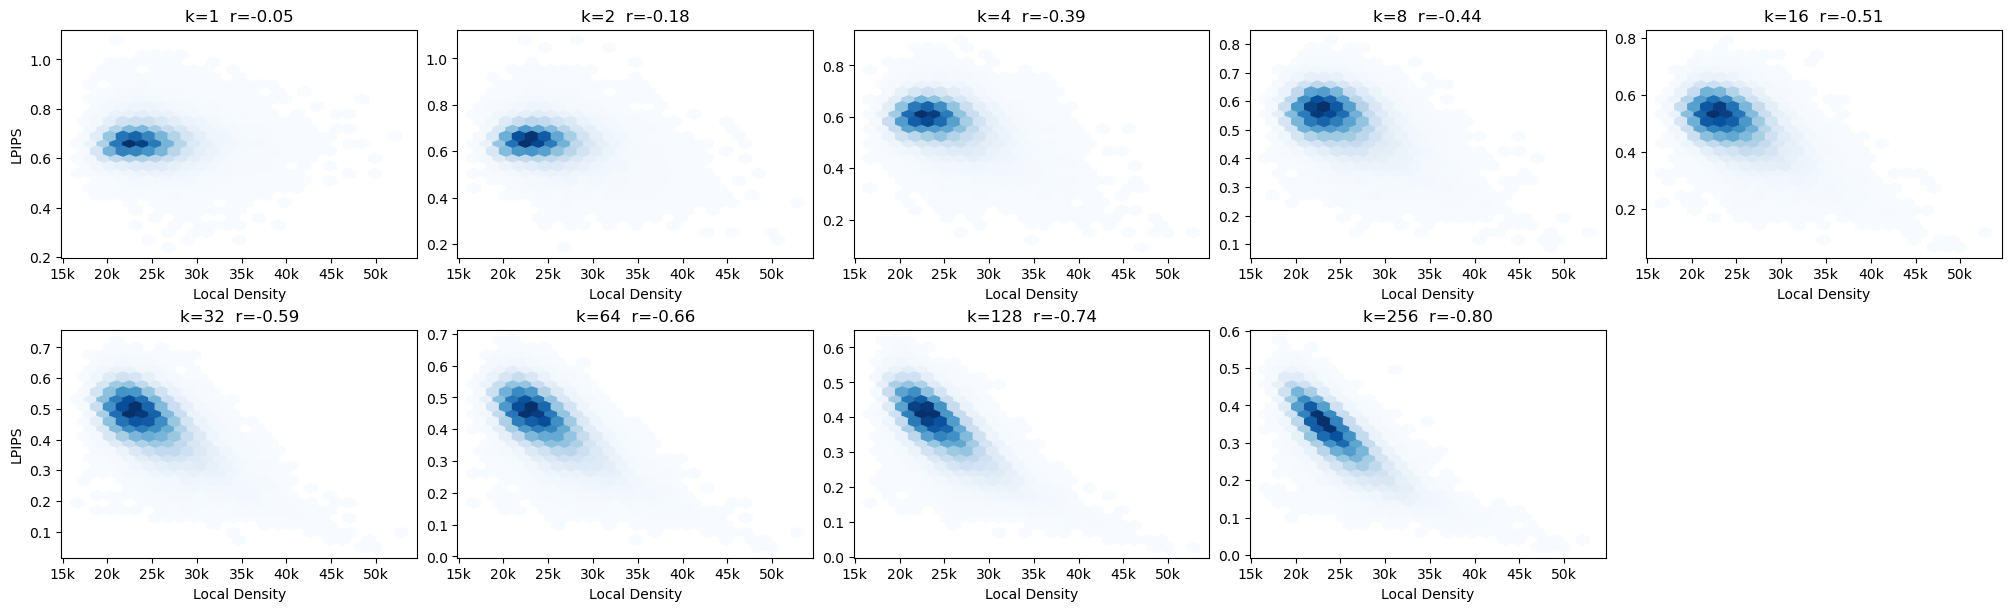

{1: {'n': 50000, 'pearson_r': -0.052438290843405316},
 2: {'n': 50000, 'pearson_r': -0.17907353108698984},
 4: {'n': 50000, 'pearson_r': -0.3854594484715914},
 8: {'n': 50000, 'pearson_r': -0.4362799067579743},
 16: {'n': 50000, 'pearson_r': -0.5068005918655262},
 32: {'n': 50000, 'pearson_r': -0.587744453386564},
 64: {'n': 50000, 'pearson_r': -0.6616160266749985},
 128: {'n': 50000, 'pearson_r': -0.739849626277351},
 256: {'n': 50000, 'pearson_r': -0.801078526517016}}

In [24]:
# Plot: for each k, scatter LID (x) vs reconstruction loss (y) with a binned trend and correlation.
# This mirrors the edge-ratio grid, with thorough comments for clarity.
# Parameters: choose which reconstruction loss to plot and which k values to include
loss_key = 'LPIPS'                 # or 'L1Loss' DINOv2FeatureLoss LPIPS
ks = [1, 2, 4, 8, 16, 32, 64, 128, 256]  # token counts to visualize
print(f"Using loss_key={loss_key}; ks={ks}")
corr_list = []

ncols = 5
nrows = int(math.ceil(len(ks) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), squeeze=False, constrained_layout=True)
axes_f = axes.flatten()

import matplotlib.ticker as mticker

def thousands_formatter(x, pos):
    if x == 0:
        return ''
    return f'{x/1000:.3g}k'

per_k_stats = {}  # {k: {'n': count, 'pearson_r': r}}
for i, k in enumerate(ks):
    ax = axes_f[i]

    # Gather pairs (x=LID, y=loss) for images that match this k and have a LID value
    xs_list, ys_list = [], []
    for rec in reconstruction_dataset:
        if int(rec['k_value']) != int(k):
            continue
        img_id = int(rec['image_id'])
        if img_id not in density_id:
            continue
        xs_list.append(density_id[img_id])       # x-axis: LID
        ys_list.append(float(rec[loss_key]))    # y-axis: reconstruction loss

    xs = np.array(xs_list, dtype=float)
    ys = np.array(ys_list, dtype=float)

    if xs.size > 0:
        # Scatter: small markers + transparency to handle dense plots
        ax.hexbin(xs, ys, gridsize=25, cmap='Blues', mincnt=1)

        # Pearson correlation (linear association); guard against zero variance
        corr = float('nan')
        if xs.size > 1 and np.std(xs) > 0 and np.std(ys) > 0:
            corr = np.corrcoef(xs, ys)[0, 1]
        per_k_stats[int(k)] = {'n': int(xs.size), 'pearson_r': corr}
        ax.set_title(f"k={k}  r={corr:.2f}")
    else:
        per_k_stats[int(k)] = {'n': 0, 'pearson_r': float('nan')}
        ax.set_title(f"k={k} (no data)")

    corr_list.append(corr)

    # Format x-axis in thousands, hide zero
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(thousands_formatter))

    # Label axes (reduce clutter: y-label only on first column)
    if i % ncols == 0:
        ax.set_ylabel(loss_key.replace('_', ' '))  # e.g., 'vgg error' or 'mse error'
    ax.set_xlabel('Local Density')

# Hide any leftover axes in the grid (when ks doesn't fill all slots)
for j in range(len(ks), len(axes_f)):
    axes_f[j].axis('off')

plt.savefig("/BS/data_mani_compress/work/thesis/thesis/output/density/density_vs_lpips_reconstruction_loss_separate.pdf", bbox_inches='tight')
plt.show()

per_k_stats


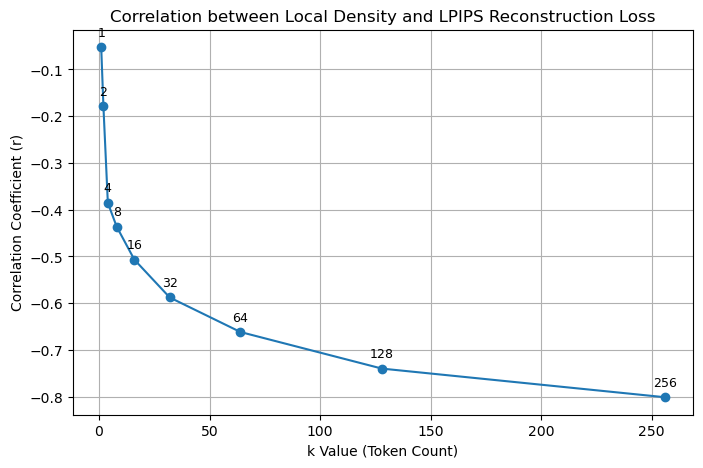

In [26]:
# plot correlation vs k_values
plt.figure(figsize=(8, 5))
plt.plot(ks, corr_list, marker='o')
#plt.xscale('log', base=2)

for x, y in zip(ks, corr_list):
    plt.annotate(
        f"{x}",          # text (x value)
        (x, y),          # point to annotate
        textcoords="offset points",
        xytext=(0, 8),   # offset above the point
        ha='center',
        fontsize=9
    )

plt.xlabel('k Value (Token Count)')
plt.ylabel('Correlation Coefficient (r)')
plt.title('Correlation between Local Density and LPIPS Reconstruction Loss')
plt.grid(True)
plt.savefig("/BS/data_mani_compress/work/thesis/thesis/output/density/density_vs_lpips_reconstruction_loss.pdf", bbox_inches='tight')
plt.show()